In [1]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets,transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
device=torch.device("cuda"if torch.cuda.is_available() else "cpu")

In [3]:
transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
train_dataset=datasets.ImageFolder(root=r"C:\Users\nishi\code\DL\COVID-19\train",transform=transform)
train_loader=DataLoader(train_dataset,batch_size=8,shuffle=True)
test_dataset=datasets.ImageFolder(root=r"C:\Users\nishi\code\DL\COVID-19\test",transform=transform)
test_loader=DataLoader(test_dataset,batch_size=2,shuffle=False)

In [4]:
for image, label in train_loader:
    print(f"image:{image.size()}")
    print(f"label:{label.size()}")
    break

image:torch.Size([8, 3, 224, 224])
label:torch.Size([8])


In [5]:
class ResnetBlock(torch.nn.Module):
    def __init__(self):
        super(ResnetBlock,self).__init__()
        self.block1=torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=(3,3),padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32,64,3,padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64,128,3,padding=1),
            torch.nn.BatchNorm2d(128),
            
        )
        self.shortcut1=torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3,out_channels=128,kernel_size=(3,3),padding=1),
            torch.nn.BatchNorm2d(128),
        )
        self.block2=torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=128,out_channels=128,kernel_size=(3,3),padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.Conv2d(128,256,3,padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.Conv2d(256,256,3,padding=1),
            torch.nn.BatchNorm2d(256),
            
        )
        self.shortcut2=torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=128,out_channels=256,kernel_size=(3,3),padding=1),
            torch.nn.BatchNorm2d(256),
        )

    def forward(self,x):
        
        block=self.block1(x)
        shortcut1=self.shortcut1(x)
        x=F.relu(block+shortcut1)
        block=self.block2(x)
        shortcut2=self.shortcut2(x)
        x=F.relu(block+shortcut2)
        return x


In [6]:
class Resnet(torch.nn.Module):
    def __init__(self):
        super(Resnet,self).__init__()
        self.resnet_block=ResnetBlock()
        self.pool=torch.nn.AdaptiveAvgPool2d((1,1))
        self.fc=torch.nn.Linear(256,2)

    def forward(self,x):
        x=self.resnet_block(x)
        x=self.pool(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)
        
        return x

In [7]:
def eval(model,device,data):
    
    model.eval()
    num_examples,correct=0,0

    for features,targets in data:
        features=features.to(device)
        targets=targets.to(device)

        logits=model(features)
        _,prediction=torch.max(logits,dim=1)
        num_examples+=targets.size(0)
        correct+=(prediction==targets).sum()

    return correct.float()/num_examples * 100
def train(model,device,train_loader,num_epochs,optimizer,scheduler):
    minibatch_loss,train_acc_list,val_acc_list=[],[],[]
    start_time=time.time()
    for epoch in range(num_epochs):
        model.train()

        for batch_idx,(features,targets) in enumerate(train_loader):
            features=features.to(device)
            targets=targets.to(device)

            logits=model(features)
            loss=F.cross_entropy(logits,targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            minibatch_loss.append(loss.item())

            if not batch_idx % 4:
                print(f'Epoch: {epoch+1:03d}/{num_epochs} |'
                      f'Batch: {batch_idx:04d}/{len(train_loader):04d} |'
                      f'loss: {loss.item():.4f}')
        
        model.eval()
        with torch.no_grad():
            train_acc=eval(model,device,train_loader)
           
            print(f'Epoch: {epoch+1:03d}/{num_epochs} |'
                  f'Train Accuracy: {train_acc:.2f}% |')
            train_acc_list.append(train_acc)
            scheduler.step(train_acc)
        time_elapsed=time.time()-start_time
        print(f'elapsed time: {time_elapsed:.03f}')
    return minibatch_loss,train_acc_list

In [9]:
model=Resnet().to(device=device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)
scheduler = ReduceLROnPlateau(optimizer, "max", factor=0.5, patience=3)
minibatch_loss,train_acc_list=train(model,device,train_loader,
                                    num_epochs=20,optimizer=optimizer,scheduler=scheduler)

Epoch: 001/20 |Batch: 0000/0019 |loss: 0.7064
Epoch: 001/20 |Batch: 0004/0019 |loss: 0.3330
Epoch: 001/20 |Batch: 0008/0019 |loss: 0.3502
Epoch: 001/20 |Batch: 0012/0019 |loss: 0.5922
Epoch: 001/20 |Batch: 0016/0019 |loss: 0.3622
Epoch: 001/20 |Train Accuracy: 50.00% |
elapsed time: 19.820
Epoch: 002/20 |Batch: 0000/0019 |loss: 0.2376
Epoch: 002/20 |Batch: 0004/0019 |loss: 0.1688
Epoch: 002/20 |Batch: 0008/0019 |loss: 0.1636
Epoch: 002/20 |Batch: 0012/0019 |loss: 0.2196
Epoch: 002/20 |Batch: 0016/0019 |loss: 0.3595
Epoch: 002/20 |Train Accuracy: 50.00% |
elapsed time: 38.901
Epoch: 003/20 |Batch: 0000/0019 |loss: 0.1187
Epoch: 003/20 |Batch: 0004/0019 |loss: 0.0937
Epoch: 003/20 |Batch: 0008/0019 |loss: 0.3858
Epoch: 003/20 |Batch: 0012/0019 |loss: 0.2832
Epoch: 003/20 |Batch: 0016/0019 |loss: 0.2301
Epoch: 003/20 |Train Accuracy: 50.00% |
elapsed time: 58.081
Epoch: 004/20 |Batch: 0000/0019 |loss: 0.2235
Epoch: 004/20 |Batch: 0004/0019 |loss: 0.4280
Epoch: 004/20 |Batch: 0008/0019 |lo

In [ ]:
# Clear GPU memory after training
torch.cuda.empty_cache()

In [10]:
test_acc=eval(model,device,test_loader)
print(f'Test Accuracy: {test_acc}')

Test Accuracy: 100.0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

all_predictions = []
all_targets = []

model.eval()
with torch.no_grad():
    for features, targets in test_loader:
        features = features.to(device)
        targets = targets.to(device)
        
        logits = model(features)
        _, predictions = torch.max(logits, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

cm = confusion_matrix(all_targets, all_predictions)
print("Confusion Matrix:")
print(cm)
print("\n" + "="*50 + "\n")

class_names = ['NORMAL', 'PNEUMONIA']
print("Classification Report:")
print(classification_report(all_targets, all_predictions, target_names=class_names))


Confusion Matrix:
[[20  0]
 [ 0 20]]


Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



<Figure size 800x600 with 0 Axes>

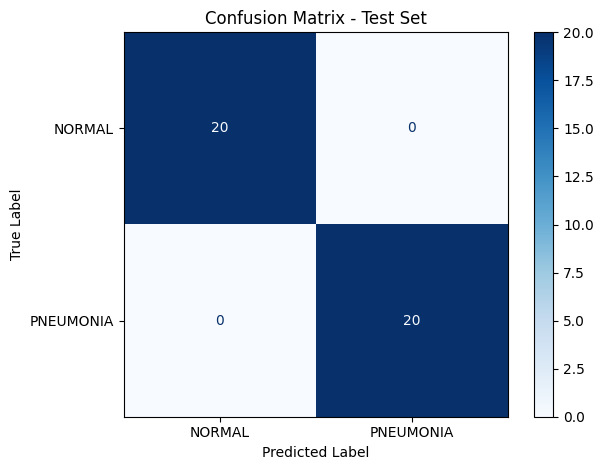

In [ ]:

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
